# Part 7: Inference in Hidden Markov Models

The definitions of state space models in `dynestyx` is quite broad, and includes things like discrete-valued states. In this case, we can use the `Filter` to obtain estimates of the log-likelihood, useful for filtering afterwards.

## The Model

To show how simple the resulting parameter learning is, we will use a common example called the "occasionally dishonest casino." This is used in the [dynamax tutorials](https://probml.github.io/dynamax/notebooks/hmm/casino_hmm_inference.html), and originates from [1].

In the occasionally dishonest casino, we play a game by rolling a die. The player rolling the die is typically rolling a fair die (i.e., $p(1) = p(2) = \dots = p(6) = 1/6$), but occasionally switches to an unfair, weighted die (with $p(1) = \dots = p(5) = 1/10$ and $p(6) = 1/2$). Let us use $z$ to indicate if the weighted die is being used: $z=0$ indicates the fair die is being used, and $z=1$ indicates the weighted die is being thrown.  

The resulting HMM is specified by the probability of transitions between each state; i.e., $p(z_{t+1} = 0 | z_t = 1)$ (for which we'll use $p_{1\to 0}$ as shorthand) and $p(z_{t+1} = 1 | z_t = 0)$ (resp., $p_{0\to 1}$). For the ground truth, we will specify that 

$$ A \triangleq \begin{bmatrix} p_{0 \to 0} & p_{0 \to 1} \\ p_{1 \to 0} & p_{1 \to 1} \end{bmatrix} = \begin{bmatrix} 0.95 & 0.05 \\ 0.1 & 0.9 \end{bmatrix}. $$

In our Bayesian model, we will place a standard Dirichlet prior over the rows of $A$ and learn $p(A \,|\, y_{1:T})$ from data.

## Writing the Model in `dynestyx`

Even though this model takes on discrete states and observations, the general structure of the resulting `dynestyx` model is the same. We'll place a prior on parameters, and then define a discrete-time dynamical model.

In [1]:
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import DynamicalModel


def hmm_model(A=None, obs_times=None, obs_values=None, predict_times=None):
    A = numpyro.sample("A", dist.Dirichlet(jnp.ones(2)).expand([2]).to_event(1), obs=A)

    def state_evolution(x, u, t_now, t_next):
        return dist.Categorical(probs=A[x])

    def observation_model(x, u, t):
        probs = jnp.array(
            [
                [1 / 6, 1 / 6, 1 / 6, 1 / 6, 1 / 6, 1 / 6],
                [1 / 10, 1 / 10, 1 / 10, 1 / 10, 1 / 10, 1 / 2],
            ]
        )
        return dist.Categorical(probs=probs[x])

    dynamics = DynamicalModel(
        initial_condition=dist.Categorical(probs=jnp.ones(2) / 2),
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

## Generating Synthetic Data

As a generic discrete-time SSM, we can generate data using the `DiscreteTimeSimulator`.

In [2]:
import jax.random as jr
from numpyro.infer import Predictive

from dynestyx import DiscreteTimeSimulator

n_rollout_eval = 100
n_train = 10000
obs_times_full = jnp.arange(start=0.0, stop=n_train + n_rollout_eval, step=1.0)
obs_times = obs_times_full[:n_train]
rollout_eval_times = obs_times_full[n_train:]

prng_key = jr.PRNGKey(0)
predictive_model = Predictive(hmm_model, num_samples=1)

true_A = jnp.array([[0.95, 0.05], [0.1, 0.9]])

with DiscreteTimeSimulator():
    synthetic_samples = predictive_model(prng_key, A=true_A, predict_times=obs_times_full)


In [3]:
# Extract observations from synthetic data.
print(
    "synthetic shapes:",
    synthetic_samples["f_times"].shape,
    synthetic_samples["f_states"].shape,
    synthetic_samples["f_observations"].shape,
)
obs_all = synthetic_samples["f_observations"][0, 0, :]
states_all = synthetic_samples["f_states"][0, 0, :]
obs_values = obs_all[:n_train]
obs_values_eval_rollout = obs_all[n_train:]

states_true = states_all[:n_train]
states_true_eval_rollout = states_all[n_train:]


synthetic shapes: (1, 1, 10100) (1, 1, 10100) (1, 1, 10100)


**Shape convention note:** simulator outputs include a leading `n_simulations` axis (size 1 by default). Under `Predictive`, there is also a leading `num_samples` axis. We handle these axes explicitly via indexing/reshaping in this notebook.

We include plotting utilities to visualize the output of an HMM.

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'HMM latent states and observations'}, xlabel='Time', ylabel='Observations'>)

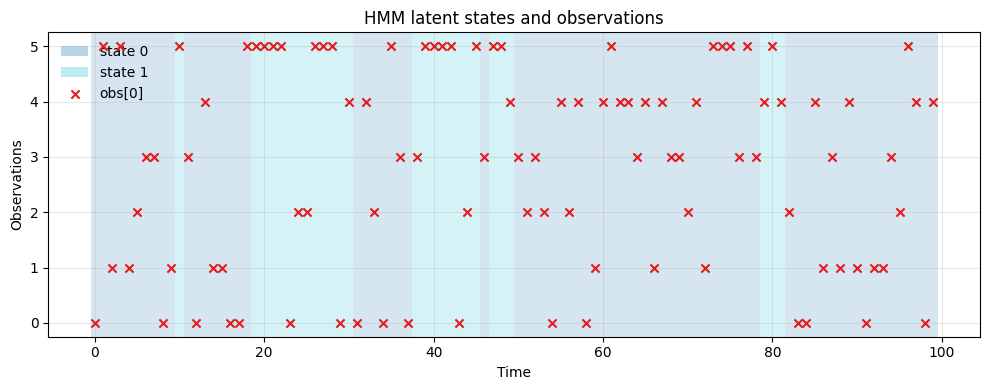

In [4]:
from dynestyx.diagnostics.plotting_utils import plot_hmm_states_and_observations

plot_hmm_states_and_observations(
    times=obs_times[:100],
    x=states_true[:100],
    y=obs_values[:100],
)

## Bayesian Inference on The Model

using the observations, we can now perform Bayesian inference on the model transition probabilities. For this, we can use the `dsx.filters.Filter` and, like usual, the standard `numpyro` inference toolkit.

We then can perform parameter inference using NUTS directly.

In [5]:
from numpyro.infer import MCMC, NUTS
from dynestyx import Filter
from dynestyx.inference.filters import HMMConfig

mcmc_key = jr.PRNGKey(0)

with Filter(filter_config=HMMConfig()):
    nuts_kernel = NUTS(hmm_model)
    mcmc = MCMC(
        nuts_kernel,
        num_samples=500,
        num_warmup=500,
    )
    mcmc.run(mcmc_key, obs_times=obs_times, obs_values=obs_values)

posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 1000/1000 [00:12<00:00, 82.62it/s, 7 steps of size 4.79e-01. acc. prob=0.94] 


We can look at the probability of transitioning $p_{0\to 1}$ and $p_{1 \to 0}$ to analyze the uncertainty and how this matches the true generating parameter:

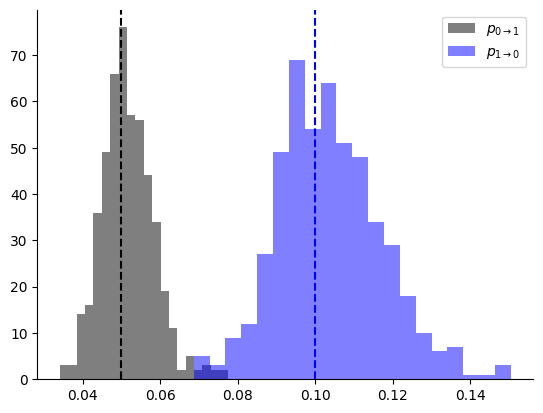

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.hist(
    posterior_samples["A"][:, 0, 1],
    bins=20,
    color="k",
    alpha=0.5,
    label=r"$p_{0\to 1}$",
)
plt.axvline(true_A[0, 1], color="k", linestyle="--")
plt.hist(
    posterior_samples["A"][:, 1, 0],
    bins=20,
    color="b",
    alpha=0.5,
    label=r"$p_{1\to 0}$",
)
plt.axvline(true_A[1, 0], color="b", linestyle="--")
sns.despine()
plt.legend()
plt.show()

## Rollout: Filter + DiscreteTimeSimulator with `predict_times`

We can push the posterior predictive filtering distribution into a **posterior predictive rollout** by combining `Filter` with `DiscreteTimeSimulator` and `predict_times`. The filter conditions on observations to obtain $p(x_t \mid y_{1:t})$ at each obs time; the simulator then rolls out trajectories from each filtered distribution at `predict_times`, including times beyond the last observation. This yields posterior predictive states and observations conditioned on the filtering distribution.

Use a dense time grid from `obs_times[0]` to `obs_times[-1] + T` to show rollout past the final filtered time.

rollout shapes: (1, 100, 100) (1, 10000, 2)


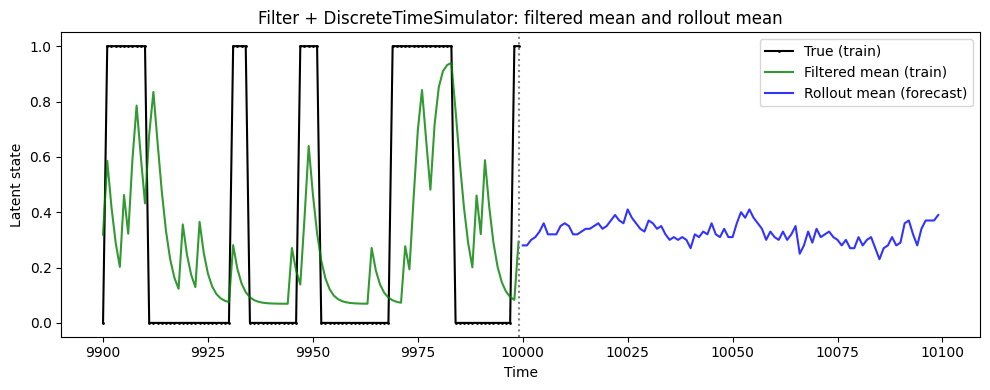

In [7]:

A_post_mean = jnp.mean(posterior_samples["A"], axis=0)
n_sim = 500
predictive = Predictive(
    hmm_model,
    params={"A": A_post_mean},
    num_samples=1,
    exclude_deterministic=False,
)
with DiscreteTimeSimulator(n_simulations=n_sim):
    with Filter(filter_config=HMMConfig(record_filtered=True)):
        samples = predictive(
            jr.PRNGKey(42),
            obs_times=obs_times,
            obs_values=obs_values,
            predict_times=rollout_eval_times,
        )

# Plot: filtered mean latent state (train) + rollout mean (forecast)
pred_states_raw = jnp.asarray(samples["f_predicted_states"])  # (num_samples, n_sim, T_pred)
filtered_probs_raw = jnp.asarray(samples["f_filtered_states"])  # (num_samples, T_train, 2)

print("rollout shapes:", pred_states_raw.shape, filtered_probs_raw.shape)

# Unlist draw axes explicitly.
pred_states = pred_states_raw.reshape((-1, pred_states_raw.shape[-1]))
filtered_probs = filtered_probs_raw.reshape((-1, filtered_probs_raw.shape[-2], filtered_probs_raw.shape[-1]))

# Filtered: P(z=1) = E[z] for 2-state HMM
filtered_mean = jnp.percentile(filtered_probs[:, :, 1], 50.0, axis=0)
rollout_mean = jnp.mean(pred_states, axis=0)

# Show last 100 timesteps of filtering, then rollout
n_show = 100
obs_times_show = obs_times[-n_show:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(obs_times_show, states_true[-n_show:], "k.-", markersize=2, label="True (train)")
ax.plot(obs_times_show, filtered_mean[-n_show:], "g-", alpha=0.8, label="Filtered mean (train)")
ax.plot(rollout_eval_times, rollout_mean, "b-", alpha=0.8, label="Rollout mean (forecast)")
ax.axvline(obs_times_show[-1], color="gray", linestyle=":")
ax.set_ylabel("Latent state")
ax.set_xlabel("Time")
ax.legend(loc="upper right")
ax.set_title("Filter + DiscreteTimeSimulator: filtered mean and rollout mean")
plt.tight_layout()
plt.show()

## References

[1] “Biological Sequence Analysis: Probabilistic Models of Proteins and Nucleic Acids” by R. Durbin, S. Eddy, A. Krogh and G. Mitchison (1998).
